# Sample Spaces, Events, and the Axioms of Probability

## Learning Objectives

By the end of this notebook you will be able to:

1. Define **random experiments**, **sample spaces**, **outcomes**, and **events** using set-theoretic language.
2. State the **Kolmogorov axioms** and derive basic probability rules from them.
3. Apply **set operations** (union, intersection, complement) to compute event probabilities.
4. Distinguish between the **classical** (Laplace) and **frequentist** interpretations of probability.
5. Explain why the **law of large numbers** bridges the two interpretations.

## Prerequisites

- Basic Python (loops, functions, lists) — see Module 00
- NumPy fundamentals (`np.random`, array operations) — see `00_prerequisites/03_numpy_essentials.ipynb`

In [1]:
# Environment detection & setup
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim ipython==8.21.0"
    )

# Ensure MiKTeX is on PATH (Windows — conda env may not inherit system PATH)
_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt

# Apply course style
sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()


class Cfg:
    """Notebook-level configuration: paths, LaTeX detection, Manim defaults."""

    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)
        if not self.has_latex:
            print("⚠ LaTeX not found — MathTex will fall back to Text().")

    # ── Manim helpers ──────────────────────────────────────────────
    def apply_manim_config(self):
        """Call after `from manim import *` to configure Manim for notebook use."""
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr: str, **kwargs):
        """MathTex if LaTeX is available, otherwise a cleaned-up Text fallback."""
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        plain = expr.replace(r"\hat{P}", "P̂").replace(r"\text{", "").replace("}", "")
        plain = plain.replace(r"\tfrac{1}{6}", "1/6").replace("$", "")
        return Text(plain, **kwargs)

    def save_gifs(self, clean: bool = True):
        """Copy final GIFs to media/gifs/ at repo root and optionally clean local temp files.

        NOTE: We never delete media/jupyter/ — Manim's %%manim magic keeps a
        reference to rendered files there.  Deleting it causes FileNotFoundError
        on re-render within the same kernel session.
        """
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  ✓ media/gifs/{gif.name}")
        if clean:
            # Clean render temp dirs but NOT jupyter/ — Manim's magic tracks files there
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()

---

## 1. Random Experiments and Sample Spaces

Probability theory begins with the idea of a **random experiment** — any process whose outcome cannot be predicted with certainty *before* it is carried out.

> **Definition 1.1 (Random experiment).** A *random experiment* is a procedure that
> (i) can be repeated under identical conditions, and
> (ii) has a well-defined set of possible outcomes, but
> (iii) the specific outcome of any single trial cannot be known in advance.

Everyday examples: flipping a coin, rolling a die, drawing a card from a shuffled deck, measuring the time between customer arrivals. In each case we know *what could happen* but not *what will happen*.

> **Definition 1.2 (Sample space).** The *sample space* $\Omega$ of a random experiment is the set of **all** possible outcomes.

| Experiment | Sample space $\Omega$ | $|\Omega|$ |
|---|---|---|
| Flip a coin | $\{H, T\}$ | 2 |
| Roll a six-sided die | $\{1, 2, 3, 4, 5, 6\}$ | 6 |
| Flip two coins | $\{HH, HT, TH, TT\}$ | 4 |
| Roll two dice | $\{(i, j) : i, j \in \{1,\dots,6\}\}$ | 36 |
| Measure a waiting time | $[0, \infty)$ | uncountable |

Notice that sample spaces can be **finite**, **countably infinite** (e.g., count the number of emails until a spam arrives), or **uncountable** (e.g., any continuous measurement). For this introductory notebook we focus on finite sample spaces; continuous spaces appear in Module 02.

Each element $\omega \in \Omega$ is called an **outcome** (or **sample point**).

---

## 2. Events and Set Operations

We are rarely interested in a single outcome. Instead, we ask questions like *"Is the die roll even?"* or *"Did at least one coin land heads?"*. These questions correspond to **events**.

> **Definition 1.3 (Event).** An *event* is any subset $A \subseteq \Omega$.

- The **certain event** is $\Omega$ itself (something must happen).
- The **impossible event** is $\varnothing$ (nothing in the sample space satisfies the condition).
- A **simple (elementary) event** contains exactly one outcome: $\{\omega\}$.

Because events are sets, we combine them with the usual set operations:

| Operation    | Notation                     | Meaning                       |
|--------------|------------------------------|-------------------------------|
| Union        | $A \cup B$                   | "$A$ or $B$ (or both) occurs" |
| Intersection | $A \cap B$                   | "Both $A$ and $B$ occur"      |
| Complement   | $A^c$                        | "$A$ does not occur"          |
| Difference   | $A \setminus B = A \cap B^c$ | "$A$ occurs but $B$ does not" |

Two events are **mutually exclusive** (or **disjoint**) if $A \cap B = \varnothing$ — they cannot both occur.

### De Morgan's Laws

These identities are used constantly in probability and are worth memorising:

$$
(A \cup B)^c = A^c \cap B^c \qquad \text{and} \qquad (A \cap B)^c = A^c \cup B^c
$$

In words: "not (A or B)" is the same as "not A *and* not B", and "not (A and B)" is the same as "not A *or* not B".

### Example: die roll

Let $\Omega = \{1, 2, 3, 4, 5, 6\}$, with events:
- $A = \{2, 4, 6\}$ — "roll an even number"
- $B = \{1, 2, 3\}$ — "roll at most 3"

Then:
- $A \cup B = \{1, 2, 3, 4, 6\}$
- $A \cap B = \{2\}$
- $A^c = \{1, 3, 5\}$
- $A \setminus B = \{4, 6\}$

In [11]:
# Verify the set operations from the example above in Python
omega = {1, 2, 3, 4, 5, 6}
A = {2, 4, 6}  # even
B = {1, 2, 3}  # at most 3

print(f"Ω       = {sorted(omega)}")
print(f"A       = {sorted(A)}")
print(f"B       = {sorted(B)}")
print(f"A ∪ B   = {sorted(A | B)}")
print(f"A ∩ B   = {sorted(A & B)}")
print(f"Aᶜ      = {sorted(omega - A)}")
print(f"A \\ B   = {sorted(A - B)}")

Ω       = [1, 2, 3, 4, 5, 6]
A       = [2, 4, 6]
B       = [1, 2, 3]
A ∪ B   = [1, 2, 3, 4, 6]
A ∩ B   = [2]
Aᶜ      = [1, 3, 5]
A \ B   = [4, 6]


---

## 3. The Axioms of Probability (Kolmogorov, 1933)

So far we have the *language* (sample spaces, events, set operations) but no way to assign numbers to events. Andrey Kolmogorov's axioms provide the foundation.

> **Definition 1.4 (Probability measure).** A function $P : \mathcal{F} \to \mathbb{R}$, where $\mathcal{F}$ is a collection of events (a $\sigma$-algebra on $\Omega$), is a *probability measure* if it satisfies:
>
> **Axiom 1 (Non-negativity).** For every event $A$,
> $$P(A) \ge 0.$$
>
> **Axiom 2 (Normalisation).** The probability of the certain event is
> $$P(\Omega) = 1.$$
>
> **Axiom 3 (Countable additivity).** If $A_1, A_2, \dots$ are pairwise disjoint events, then
> $$P\!\left(\bigcup_{i=1}^{\infty} A_i\right) = \sum_{i=1}^{\infty} P(A_i).$$

The triple $(\Omega, \mathcal{F}, P)$ is called a **probability space**. For finite sample spaces the $\sigma$-algebra is simply the power set $\mathcal{F} = 2^\Omega$ (the set of all subsets), so we won't worry about $\sigma$-algebras further in this notebook.

### Key consequences of the axioms

Everything else in probability theory is *derived* from these three axioms. Here are the most important immediate results:

| Property            | Statement                                 | Derivation sketch                                                         |
|---------------------|-------------------------------------------|---------------------------------------------------------------------------|
| Complement rule     | $P(A^c) = 1 - P(A)$                       | $A$ and $A^c$ are disjoint, $A \cup A^c = \Omega$, so $P(A) + P(A^c) = 1$ |
| Impossible event    | $P(\varnothing) = 0$                      | $\varnothing = \Omega^c$, apply complement rule                           |
| Bounds              | $0 \le P(A) \le 1$                        | Non-negativity + complement rule                                          |
| Monotonicity        | If $A \subseteq B$ then $P(A) \le P(B)$   | $B = A \cup (B \setminus A)$, disjoint                                    |
| Inclusion–exclusion | $P(A \cup B) = P(A) + P(B) - P(A \cap B)$ | Write $A \cup B$ as disjoint union                                        |

The **inclusion–exclusion** formula is particularly important. For disjoint events ($A \cap B = \varnothing$), it reduces to $P(A \cup B) = P(A) + P(B)$, which is just Axiom 3 for two events.

---

## 4. Classical (Laplace) Probability

The oldest approach to assigning probabilities comes from Pierre-Simon Laplace (1814). If a random experiment has **finitely many, equally likely** outcomes, then the probability of an event is simply the ratio of favourable outcomes to total outcomes:

$$
P(A) = \frac{|A|}{|\Omega|} = \frac{\text{number of outcomes in } A}{\text{total number of outcomes}}
$$

This formula satisfies the Kolmogorov axioms (verify this as an exercise!) and is the starting point for many combinatorial probability problems.

### Example: fair die

Let $\Omega = \{1, 2, 3, 4, 5, 6\}$ with each face equally likely. For the event $A = \{2, 4, 6\}$ ("roll an even number"):

$$P(A) = \frac{|A|}{|\Omega|} = \frac{3}{6} = \frac{1}{2}$$

In [12]:
# Classical probability: rolling a fair die
omega = {1, 2, 3, 4, 5, 6}
A = {n for n in omega if n % 2 == 0}  # event: roll an even number

P_A = len(A) / len(omega)
print(f"Ω = {sorted(omega)}")
print(f"A (even) = {sorted(A)}")
print(f"P(A) = |A|/|Ω| = {len(A)}/{len(omega)} = {P_A:.4f}")

# Inclusion-exclusion example
B = {1, 2, 3}  # at most 3
P_B = len(B) / len(omega)
P_A_and_B = len(A & B) / len(omega)
P_A_or_B = len(A | B) / len(omega)

print(f"\nB (≤ 3) = {sorted(B)}")
print(f"P(B)     = {P_B:.4f}")
print(f"P(A ∩ B) = {P_A_and_B:.4f}")
print(
    f"P(A ∪ B) = P(A) + P(B) - P(A ∩ B) = {P_A} + {P_B} - {P_A_and_B} = {P_A_or_B:.4f}"
)

Ω = [1, 2, 3, 4, 5, 6]
A (even) = [2, 4, 6]
P(A) = |A|/|Ω| = 3/6 = 0.5000

B (≤ 3) = [1, 2, 3]
P(B)     = 0.5000
P(A ∩ B) = 0.1667
P(A ∪ B) = P(A) + P(B) - P(A ∩ B) = 0.5 + 0.5 - 0.16666666666666666 = 0.8333


### Limitations of the classical approach

Laplace's formula is elegant but limited:

1. It **requires equally likely outcomes** — it cannot handle a biased coin or a loaded die.
2. It is **circular** if taken as a *definition*: we say outcomes are "equally likely" (i.e., equally *probable*) and then use that to define probability.
3. It only applies to **finite** sample spaces.

This motivates a second viewpoint: the **frequentist interpretation**.

---

## 5. The Frequentist Interpretation and the Law of Large Numbers

The **frequentist** interpretation defines probability as a long-run relative frequency:

> If we repeat a random experiment $n$ times, and event $A$ occurs $n_A$ times, then
>
> $$P(A) \approx \frac{n_A}{n} \quad \text{for large } n.$$

More precisely, the **law of large numbers** (which we will prove in Module 02) guarantees that the relative frequency converges to the true probability:

$$
\hat{P}_n(A) = \frac{n_A}{n} \xrightarrow{\;n \to \infty\;} P(A)
$$

This is a *theorem*, not an axiom — it follows from the Kolmogorov axioms applied to independent, identically distributed trials. But it is also what makes probability *useful in practice*: we can **estimate** $P(A)$ by running an experiment many times and counting.

### Visualising convergence

The animation below illustrates this convergence for a fair coin ($P(\text{Heads}) = 0.5$). Watch how the relative frequency $\hat{P}_n$ is erratic for small $n$ but stabilises near $0.5$ as $n$ grows — this is the law of large numbers in action.

In [2]:
from manim import *

cfg.apply_manim_config()

# Import course color palette — use these instead of Manim's built-in BLUE, RED, etc.
from amstats.manim_utils import C, COLORS, PALETTE

# Convenience alias used in scenes below
math_text = cfg.math_text

Manim Community v0.18.1

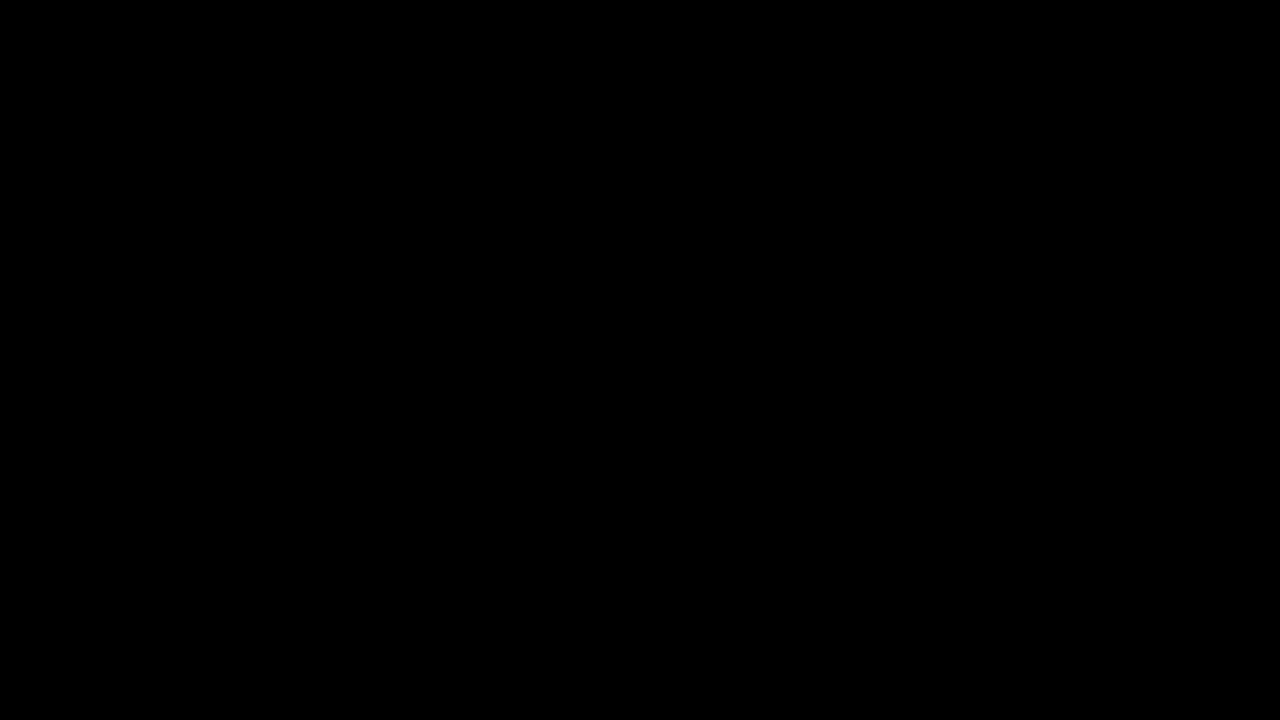

In [3]:
%%manim -qm -v WARNING CoinFlipConvergence


class CoinFlipConvergence(Scene):
    """Animate the relative frequency of heads converging to 0.5."""

    def construct(self):
        axes = Axes(
            x_range=[0, 200, 50],
            y_range=[0, 1, 0.25],
            x_length=10,
            y_length=5,
            axis_config={"include_numbers": True, "font_size": 22},
        )
        x_label = axes.get_x_axis_label(
            Text("Number of flips", font_size=22), edge=DOWN, direction=DOWN
        )
        y_label = axes.get_y_axis_label(
            math_text(r"\hat{P}(\text{Heads})", font_size=28), edge=LEFT, direction=LEFT
        )
        title = Text(
            "Coin Flip: Convergence of Relative Frequency", font_size=28
        ).to_edge(UP)

        h_line = axes.plot(
            lambda x: 0.5, x_range=[0, 200], color=C.GOLD, stroke_width=2
        )
        h_label = math_text(r"P = 0.5", font_size=22, color=C.GOLD).next_to(
            h_line, RIGHT
        )

        self.play(
            Create(axes), Write(x_label), Write(y_label), Write(title), run_time=1.5
        )
        self.play(Create(h_line), Write(h_label), run_time=0.8)

        rng = np.random.default_rng(42)
        n_flips = 200
        flips = rng.choice([0, 1], size=n_flips)

        cumulative_heads = np.cumsum(flips)
        relative_freq = cumulative_heads / np.arange(1, n_flips + 1)

        points = [axes.c2p(i + 1, relative_freq[i]) for i in range(n_flips)]

        path = VMobject(color=C.PERIWINKLE, stroke_width=3)
        path.set_points_as_corners([points[0], points[0]])
        self.add(path)

        chunk_sizes = [1, 1, 1, 2, 5, 10, 20, 40, 120]
        idx = 0
        for chunk in chunk_sizes:
            end = min(idx + chunk, n_flips)
            if idx >= n_flips:
                break
            new_path = VMobject(color=C.PERIWINKLE, stroke_width=3)
            new_path.set_points_as_corners(points[:end])
            self.play(Transform(path, new_path), run_time=0.5)
            idx = end

        final_val = relative_freq[-1]
        final_dot = Dot(points[-1], color=C.EMERALD, radius=0.08)
        final_label = math_text(
            rf"\hat{{P}} = {final_val:.3f}", font_size=24, color=C.EMERALD
        ).next_to(final_dot, UR, buff=0.15)
        self.play(FadeIn(final_dot), Write(final_label))
        self.wait(1.5)

The animation shows a *single* random sequence. A natural question is: **how much variability is there between different sequences?** The static plot below shows five independent runs. Each path wanders differently for small $n$, but they all converge to the same theoretical value $P = 0.5$ — a striking empirical demonstration of the law of large numbers.

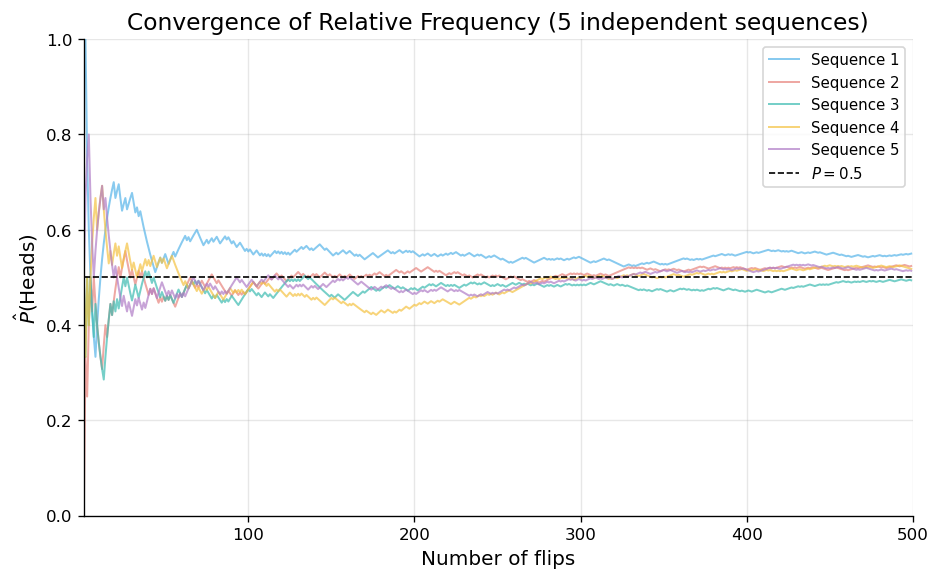

In [ ]:
# Static plot: multiple independent coin-flip sequences
rng = np.random.default_rng(0)
n_flips = 500
n_sequences = 5

fig, ax = plt.subplots()
for i in range(n_sequences):
    flips = rng.choice([0, 1], size=n_flips)
    cum_freq = np.cumsum(flips) / np.arange(1, n_flips + 1)
    ax.plot(cum_freq, alpha=0.7, linewidth=1.2, label=f"Sequence {i + 1}")

ax.axhline(0.5, color="black", linestyle="--", linewidth=1, label=r"$P = 0.5$")
ax.set_xlabel("Number of flips")
ax.set_ylabel(r"$\hat{P}(\mathrm{Heads})$")
ax.set_title("Convergence of Relative Frequency (5 independent sequences)")
ax.legend(fontsize=9)
ax.set_xlim(1, n_flips)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

Note how the static plot adds value beyond the animation: it shows **five sequences simultaneously**, making the *spread* of relative frequencies visible. The animation showed *one* path in detail; the static plot shows the *distribution* of paths. This is a recurring pattern in the course — we use animations for dynamic intuition and static plots for comparison and exploration.

---

## 6. From Theory to Simulation: The Uniform Distribution on a Die

Let us apply both the classical and frequentist viewpoints to a concrete experiment: rolling a fair die.

**Classical analysis.** Under the assumption that all faces are equally likely:

$$P(\{k\}) = \frac{1}{6} \quad \text{for each } k \in \{1, 2, 3, 4, 5, 6\}$$

This is the **discrete uniform distribution** on $\{1, \dots, 6\}$. We can verify that the axioms are satisfied:
- $P(\{k\}) = 1/6 \ge 0$ (Axiom 1)
- $\sum_{k=1}^{6} P(\{k\}) = 6 \cdot \frac{1}{6} = 1$ (Axiom 2)
- Additivity holds because we defined probabilities on individual outcomes (Axiom 3)

**Frequentist prediction.** If we roll the die $n$ times, the relative frequency of each face should approach $1/6 \approx 0.1667$ as $n$ grows.

The animation below simulates this: we roll the die in batches of increasing size and watch the histogram of relative frequencies flatten toward the theoretical $1/6$ line.

Manim Community v0.18.1

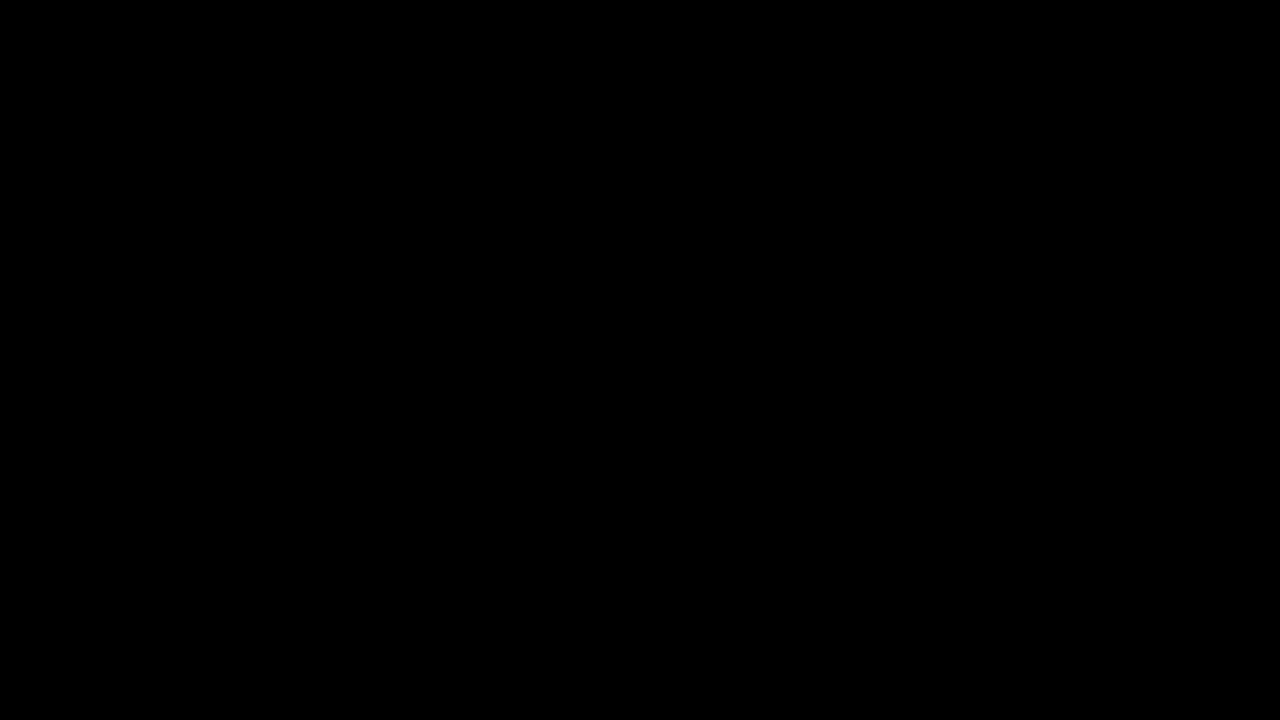

In [4]:
%%manim -qm -v WARNING DiceHistogram


class DiceHistogram(Scene):
    """Animate a histogram of die rolls building up over time."""

    def construct(self):
        title = Text("Rolling a Fair Die — Histogram", font_size=30).to_edge(UP)
        self.play(Write(title))

        axes = Axes(
            x_range=[0.5, 6.5, 1],
            y_range=[0, 0.25, 0.05],
            x_length=8,
            y_length=4.5,
            axis_config={"include_numbers": True, "font_size": 22},
        ).shift(DOWN * 0.3)
        x_label = axes.get_x_axis_label(
            Text("Die face", font_size=20), edge=DOWN, direction=DOWN
        )
        y_label = axes.get_y_axis_label(
            Text("Relative frequency", font_size=20), edge=LEFT, direction=LEFT
        )
        self.play(Create(axes), Write(x_label), Write(y_label))

        for face in range(1, 7):
            mark = DashedLine(
                axes.c2p(face, 0),
                axes.c2p(face, 1 / 6),
                color=C.GOLD,
                stroke_width=1.5,
                dash_length=0.05,
            )
            self.add(mark)
        theory_label = math_text(r"\tfrac{1}{6}", font_size=20, color=C.GOLD).next_to(
            axes.c2p(6.5, 1 / 6), RIGHT
        )
        self.play(Write(theory_label), run_time=0.5)

        rng = np.random.default_rng(7)
        bar_width = 0.6
        total_rolls = np.array([], dtype=int)
        batches = [10, 40, 150, 800, 4000]
        bars = VGroup()

        for batch_size in batches:
            new_rolls = rng.integers(1, 7, size=batch_size)
            total_rolls = np.concatenate([total_rolls, new_rolls])
            counts = np.bincount(total_rolls, minlength=7)[1:]
            freqs = counts / counts.sum()

            new_bars = VGroup()
            for face in range(6):
                bar = Rectangle(
                    width=bar_width,
                    height=max(freqs[face] * (4.5 / 0.25), 0.01),
                    fill_color=C.SALMON,
                    fill_opacity=0.7,
                    stroke_color=WHITE,
                    stroke_width=1,
                )
                bar.move_to(axes.c2p(face + 1, freqs[face] / 2))
                new_bars.add(bar)

            n_label = Text(
                f"n = {len(total_rolls)}", font_size=22, color=C.EMERALD
            ).to_corner(UR)

            if len(bars) == 0:
                self.play(FadeIn(new_bars), FadeIn(n_label), run_time=0.8)
                bars = new_bars
                prev_label = n_label
            else:
                self.play(
                    Transform(bars, new_bars),
                    Transform(prev_label, n_label),
                    run_time=0.8,
                )

        self.wait(1.5)

At $n = 10$ the histogram is jagged — some faces appear much more often than others purely by chance. By $n = 5{,}000$ the bars have nearly equalised at $1/6$, exactly as the classical analysis predicts. This is the frequentist interpretation made visible: **probability is what relative frequency converges to**.

---

## 7. Worked Example: Two-Dice Experiment

Rolling two fair dice is one of the most instructive sample spaces in introductory probability because its structure reveals subtleties that a single die hides.

**Sample space.** Each die is independent, so the sample space is the Cartesian product:

$$\Omega = \{(i, j) : i, j \in \{1, 2, 3, 4, 5, 6\}\}$$

with $|\Omega| = 6 \times 6 = 36$ equally likely outcomes.

**Event: sum equals 7.** Let $S = \{(i, j) \in \Omega : i + j = 7\}$. The favourable outcomes are:

$$ S = \{(1,6),\; (2,5),\; (3,4),\; (4,3),\; (5,2),\; (6,1)\} $$

so $|S| = 6$ and

$$P(S) = \frac{6}{36} = \frac{1}{6} \approx 0.1667$$

Let's verify this with a simulation:

Simulated P(sum = 7) = 0.1688  (theoretical: 0.1667)


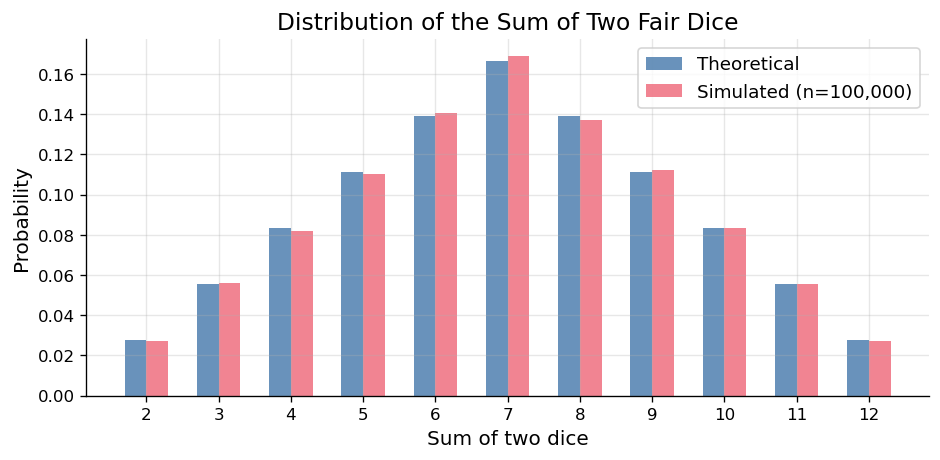

In [ ]:
# Simulation: P(sum = 7) for two fair dice
rng = np.random.default_rng(42)
n_rolls = 100_000

die_1 = rng.integers(1, 7, size=n_rolls)
die_2 = rng.integers(1, 7, size=n_rolls)
sums = die_1 + die_2

freq_7 = np.mean(sums == 7)
print(f"Simulated P(sum = 7) = {freq_7:.4f}  (theoretical: {1 / 6:.4f})")

# Distribution of all possible sums
fig, ax = plt.subplots(figsize=(8, 4))
sum_values = range(2, 13)
# Theoretical counts: number of ways to make each sum
theoretical = [min(s - 1, 13 - s) for s in sum_values]
theoretical_probs = [t / 36 for t in theoretical]

ax.bar(
    [s - 0.15 for s in sum_values],
    theoretical_probs,
    width=0.3,
    label="Theoretical",
    alpha=0.8,
)
ax.bar(
    [s + 0.15 for s in sum_values],
    [np.mean(sums == s) for s in sum_values],
    width=0.3,
    label=f"Simulated (n={n_rolls:,})",
    alpha=0.8,
)
ax.set_xlabel("Sum of two dice")
ax.set_ylabel("Probability")
ax.set_title("Distribution of the Sum of Two Fair Dice")
ax.set_xticks(list(sum_values))
ax.legend()
plt.tight_layout()
plt.show()

The triangular shape of the distribution is no coincidence. The sum $S = i + j$ can equal $k$ in $\min(k-1,\, 13-k)$ ways (think about it: for $k=7$ there are 6 ways, for $k=2$ or $k=12$ there is only 1). This is an early example of how **counting the favourable outcomes** — a topic we explore in depth in the next notebook on combinatorics — directly determines the probability distribution.

---

## Exercises

**Exercise 1.1 (Set operations).** Let $\Omega = \{1, 2, \dots, 10\}$, $A = \{1, 2, 3, 4\}$, and $B = \{3, 4, 5, 6, 7\}$. Compute by hand and then verify in Python:
- $A \cup B$, $A \cap B$, $A^c$, $B \setminus A$
- $P(A)$, $P(A \cup B)$, and verify the inclusion–exclusion formula.

**Exercise 1.2 (Axiom check).** Prove that Laplace's formula $P(A) = |A|/|\Omega|$ satisfies all three Kolmogorov axioms for a finite sample space with equally likely outcomes.

**Exercise 1.3 (Complement rule).** A standard deck has 52 cards. What is $P(\text{not an ace})$? Compute it two ways: (a) directly, and (b) using the complement rule.

**Exercise 1.4 (Simulation).** Modify the coin flip convergence plot to use a **biased** coin with $P(\text{Heads}) = 0.7$. Does the relative frequency still converge? To what value? What does this tell you about the law of large numbers?

**Exercise 1.5 (Two-dice).** For the two-dice experiment:
- Compute $P(\text{sum} \ge 10)$ analytically.
- Compute $P(\text{both dice show the same face})$ — this event is called *doubles*.
- Are the events "sum $\ge$ 10" and "doubles" mutually exclusive? Compute $P(\text{sum} \ge 10 \cup \text{doubles})$.

**Exercise 1.6 (Challenge).** A bag contains 3 red, 2 blue, and 5 green marbles. You draw **two** marbles *without replacement*.
- Write out the sample space. (*Hint:* outcomes are ordered pairs.)
- Compute $P(\text{both red})$ using the classical formula.
- Simulate 10,000 draws and compare.

---

## Key Takeaways

1. A **sample space** $\Omega$ lists every possible outcome; an **event** is any subset $A \subseteq \Omega$.
2. Events combine via **set operations** (union, intersection, complement); De Morgan's laws link these operations.
3. The **Kolmogorov axioms** (non-negativity, normalisation, countable additivity) are the foundation of all probability theory. Key results like the complement rule and inclusion–exclusion follow directly.
4. **Classical probability** ($P(A) = |A|/|\Omega|$) applies when outcomes are equally likely — elegant but limited.
5. The **frequentist interpretation** sees probability as the limit of relative frequency. The **law of large numbers** makes this rigorous.
6. Simulation is a powerful tool for **verifying** analytical results and building intuition, but the theory comes first.

**Next:** [02_combinatorics.ipynb](02_combinatorics.ipynb) — Counting techniques (permutations, combinations) that let us compute $|A|$ and $|\Omega|$ for complex experiments.

In [5]:
# Save final GIFs to media/gifs/ at repo root and clean up local temp render files.
# Set clean=False to keep the temp files for debugging.
cfg.save_gifs(clean=True)

  ✓ media/gifs/CoinFlipConvergence@2026-03-19@12-05-35.gif
  ✓ media/gifs/CoinFlipConvergence@2026-03-19@12-10-14.gif
  ✓ media/gifs/CoinFlipConvergence@2026-03-19@13-42-51.gif
  ✓ media/gifs/DiceHistogram@2026-03-19@13-43-26.gif
  ✓ media/gifs/CoinFlipConvergence_ManimCE_v0.18.1.gif
  ✓ media/gifs/DiceHistogram_ManimCE_v0.18.1.gif
  Cleaned up local temp render files (kept media/jupyter/).
